First 5 Rows:

            Timestamp                       Email Address  \
0  1/17/2022 12:45:09       sejal.zambare19@pccoepune.org   
1  1/17/2022 12:45:44    rushikesh.thorat19@pccoepune.org   
2  1/17/2022 12:46:10     atharv.sontakke19@pccoepune.org   
3  1/17/2022 12:46:21     amisha.sherekar19@pccoepune.org   
4  1/17/2022 12:46:31  saurabh.sawardekar19@pccoepune.org   

                      Name                               Email  Roll no   \
0            Sejal Zambare           sejal.zambare19@gmail.com  TECOC359   
1   Rushikesh Vilas Thorat    rushikesh.thorat19@pccoepune.org  TECOC347   
2          Atharv Sontakke         atharv123sontakke@gmail.com  TECOC340   
3    Amisha Sunil Sherekar     amisha.sherekar19@pccoepune.org  TECOC328   
4  Saurabh Raju Sawardekar  saurabh.sawardekar19@pccoepune.org  TECOC326   

     PRN No.  Mobile No.  First year:   Sem 1  First year:   Sem 2  \
0  72026841K  8208217782                 8.40                 8.60   
1  72026776F  9021261

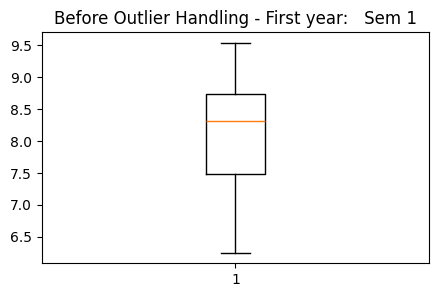

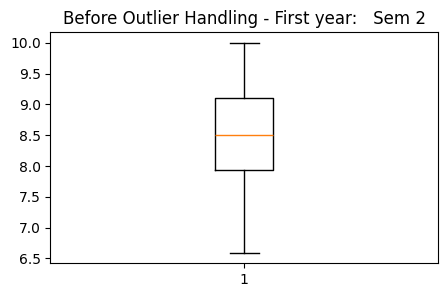

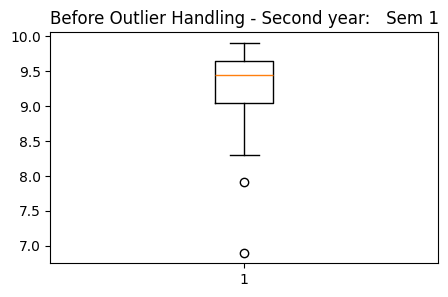

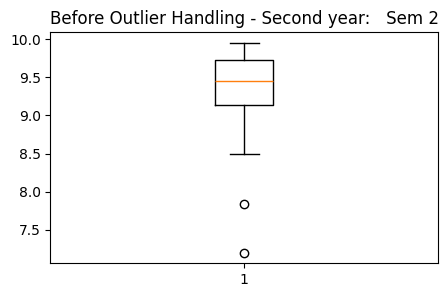


Boxplots After Outlier Handling


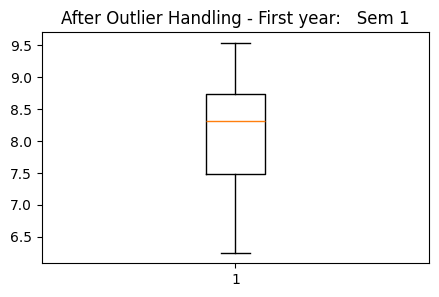

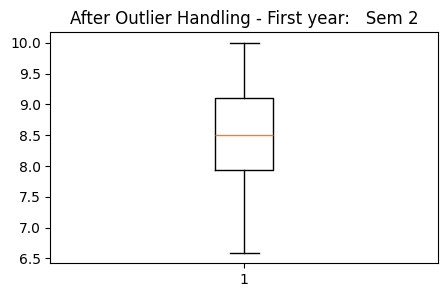

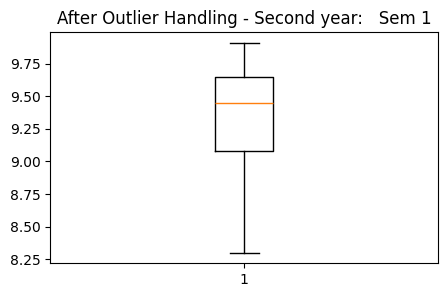

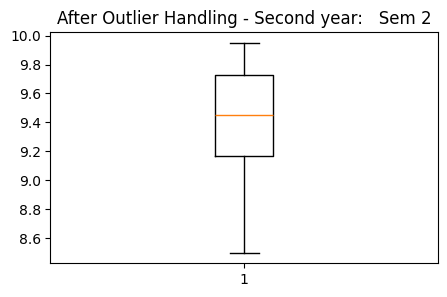


Cleaned and Transformed Dataset:

            Timestamp                       Email Address  \
0  1/17/2022 12:45:09       sejal.zambare19@pccoepune.org   
1  1/17/2022 12:45:44    rushikesh.thorat19@pccoepune.org   
2  1/17/2022 12:46:10     atharv.sontakke19@pccoepune.org   
3  1/17/2022 12:46:21     amisha.sherekar19@pccoepune.org   
4  1/17/2022 12:46:31  saurabh.sawardekar19@pccoepune.org   

                      Name                               Email  Roll no   \
0            Sejal Zambare           sejal.zambare19@gmail.com  TECOC359   
1   Rushikesh Vilas Thorat    rushikesh.thorat19@pccoepune.org  TECOC347   
2          Atharv Sontakke         atharv123sontakke@gmail.com  TECOC340   
3    Amisha Sunil Sherekar     amisha.sherekar19@pccoepune.org  TECOC328   
4  Saurabh Raju Sawardekar  saurabh.sawardekar19@pccoepune.org  TECOC326   

     PRN No.  Mobile No.  First year:   Sem 1  First year:   Sem 2  \
0  72026841K  8208217782             0.653495             0.589443   
1

In [4]:
# Data Wrangling II
# Academic Performance Dataset

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Step 2: Load Dataset
df = pd.read_csv("tecdiv.csv")

# Step 3: Display Dataset Information
print("First 5 Rows:\n")
print(df.head())

print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

# Step 4: Select Academic Columns
academic_cols = [
    'First year:   Sem 1',
    'First year:   Sem 2',
    'Second year:   Sem 1',
    'Second year:   Sem 2'
]

# Step 5: Detect Inconsistent Values
print("\nStatistical Summary:\n")

for col in academic_cols:
    print("\n", col)
    print(df[col].describe())

# Step 6: Handle Missing and Inconsistent Values
for col in academic_cols:
    
    # Replace 0 with NaN
    df[col] = df[col].replace(0, np.nan)
    
    # Replace values greater than 10 with NaN
    df.loc[df[col] > 10, col] = np.nan
    
    # Fill missing values using median
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# Step 7: Boxplot Before Handling Outliers
print("\nBoxplots Before Outlier Handling")

for col in academic_cols:
    plt.figure(figsize=(5, 3))
    plt.boxplot(df[col])
    plt.title(f"Before Outlier Handling - {col}")
    plt.show()

# Step 8: Handle Outliers Using IQR Method
for col in academic_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    median_value = df[col].median()
    
    df.loc[(df[col] < lower) | (df[col] > upper), col] = median_value

# Step 9: Boxplot After Handling Outliers
print("\nBoxplots After Outlier Handling")

for col in academic_cols:
    plt.figure(figsize=(5, 3))
    plt.boxplot(df[col])
    plt.title(f"After Outlier Handling - {col}")
    plt.show()

# Step 10: Apply Data Transformation
scaler = MinMaxScaler()

df[academic_cols] = scaler.fit_transform(df[academic_cols])

# Step 11: Display Final Dataset
print("\nCleaned and Transformed Dataset:\n")
print(df.head())